# **Geophysics Lab 3: Seismic Refraction - Wave and Ray Tracing**
Name: Firstname Lastname

**If you don't put your name in both the spot above AND the filename, you will not receive a grade for this lab.** Double-click this cell to add your name, run the cell when you're done.

**NB:** In the filename, please **do not** put any spaces between words or wildcard characters. I access all of your submissions from my command line, and you are harshing my vibe with the spaces. Thanks!

In [ ]:
# run this cell to import some of the packages needed to complete this lab:
import numpy as np               # more on numpy here:       https://numpy.org/doc/stable/user/absolute_beginners.html
import matplotlib.pyplot as plt  # more on matplotlib here:  https://matplotlib.org/stable/users/explain/quick_start.html

In [ ]:
########## !!! PLEASE try to INSTALL the packages in this cell before you start the lab !!! ##########
########## !!! this cell will NOT work if you don't already have the packages installed !!! ##########

# we are importing some other packages 'early' to see if you will have any issues with imports in this lab:
import obspy                     # more on obspy here:       https://docs.obspy.org/
from pyrocko import cake         # more on pyrocko here:     https://pyrocko.org/docs/current/index.html
#import tqdm                      # more on tdqm here:        https://github.com/tqdm/tqdm#tqdm

# if this cell returns an error, you might not have the necessary packages installed. 
# if you can't figure out the installation, please contact your TA ASAP!

This lab focuses on seismic refraction, using wave and ray tracing. There are two sections, and both have problems for you to solve throughout the section.

 ### **Section 1: Plotting travel-time curves in Python**

Imagine a source at the surface located 10 m from the first receiver, or geophone, in a 10-geophone line. The spacing between geophones is 10 m. We also know that the thickness of the layer closest to the surface is 20 m.

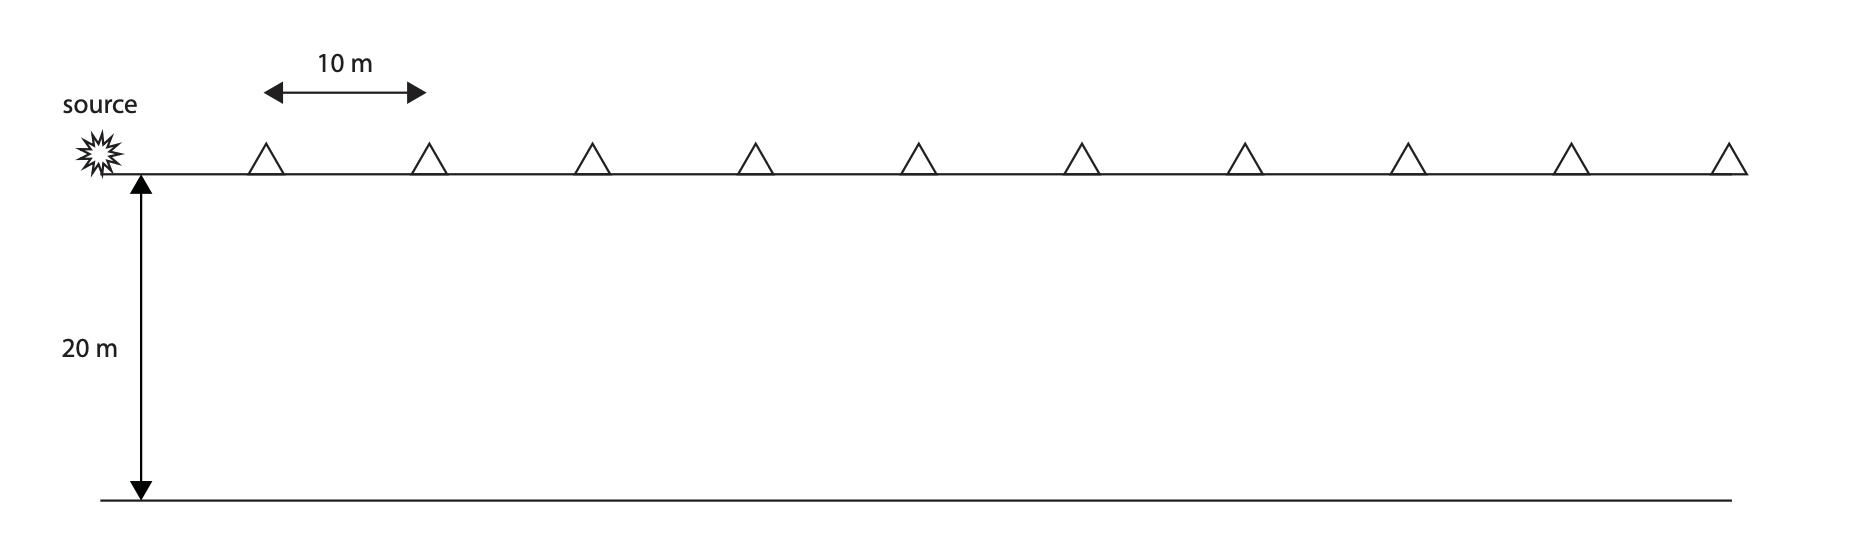

**Problem 1.1:** \
Write code that meets the criteria below to calculate the travel-time curves for the **direct** and **refracted** waves using the above configuration. Save the calculation in `t_dir` and `t_ref`.

* Assume the velocity of layer 1 is $v_1 = 2000$ m/s and the velocity of layer 2 is $v_2 = 4000$ m/s.

* This code should be similar to the code you wrote for Lab 2. Use vector operations, not a FOR loop, to do these calculations.

* The travel-time equation for refracted waves is provided below:
\begin{equation}
\tag{1.1}
t_{\text{refracted}} = \frac{x}{v_2} + 2d \frac{\sqrt{v_{2}^2 - v_{1}^2}}{v_1 v_2}
\end{equation}
Where $x =$ offset distance, $d=$ layer thickness. _(1 point)_

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code

x  = np.arange(10, 101, 10)
d  = ...

v1 = ...
v2 = ...

t_dir = ... # direct wave travel time -- this is your final answer!
t_ref = ... # refracted wave travel time -- this is your final answer!

**Problem 1.2:** \
Plot the travel-time curves together on the same plot, for **both** the direct wave and the refracted wave. Make sure to label axes and add a legend. Show your plot below.  _(1 point)_

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code
plt.figure(figsize=(10, 5), dpi=100)
plt.plot()
...
plt.show();

**Problem 1.3:** \
Answer the following questions about the travel time curves you created above.  _(2 points)_

a. What is the slope of the **direct wave** curve?

b. What is the slope of the **refracted wave** curve?

c. What physical quantity can be derived from the slopes of these curves?

d. Why is the slope of the refracted wave curve **shallower** than that of the direct wave curve?

_Double-click this cell and replace this text with your answers to Problem 1.3. Run the cell when you're done._

 ### **Section 2: Using 'Cake' to create time-distance plots**

`cake` is part of `pyrocko`, which is a set of Python toolkits that can be used to solve classical seismic ray theory problems for layered earth models (also called 'layer cake models'). You can use preloaded models for ray tracing, or define your own (layered) Earth model. 

Learn more about this interesting package at https://pyrocko.org/docs/current/apps/cake/manual.html

In [ ]:
from pyrocko import cake

As mentioned, `cake` has several pre-defined Earth models like PREM. We can load it and print all the discontinuities in the PREM model. Some of the major interfaces you can find are the surface, Moho, CMB and ICB.

In [ ]:
prem = cake.load_model("prem-no-ocean.m")

for interface in prem.discontinuities():
    print(interface)

We now learn how to define our own Earth model and to solve the seismic ray tracing problem. An Earth model in cake is made by **Interfaces** and **Layers**. 

There are two types of interfaces in cake: `Surface` and `Interface`. You need to define the depth of the interface (in meters), and the material above/below the interface (You don't need to define the material above the interface if you are using the `Surface`). 

There are also two types of layers in cake: `HomogeneousLayer` and `GradientLayer`. Here, we will only define layers to be homogeneous. 

Code below defines a layered model, with one 20 meters homogeneous layer. The Vp of layer1 is `2000 (m/s)`, while Vs is `2000/1.78 (m/s)`. **In this lab, we won't use S-wave phases, so it is safe to assume Vs=Vp/1.78**

In [ ]:
m_layer1 = cake.Material(vp = 2000., vs = 2000/1.78) # define the material in layer 1

model = cake.LayeredModel()                                           # create an empty model
model.append(cake.Surface(z = 0., mbelow = m_layer1))                 # add the surface
model.append(cake.HomogeneousLayer(0., 20., m_layer1, name='layer1')) # add the first layer

We then define the source to be 0 meters depth, and arrange the receivers. Note that cake does not allow source to be strictly located at zero depth, so we use a very small depth (0.01 meter). It changes the travel time very slightly so it is ok. We also define receivers every 10 meters (10, 20, 30, 40, ..., 100), and convert it to degree by multiplying a constant `cake.m2d`.

In [ ]:
source_depth = 0.01 # in meters
distances = np.arange(10, 101, 10) * cake.m2d  # convert meter to degree

We also need to define the phases of interest for the ray tracing. Here the small `p` indicates that we are calculating P-wave that departing upward from the source (upward take-off direction). This is the direct wave from the source to the receiver.

Refer to the manual for more complex phase definition at https://pyrocko.org/docs/current/library/reference/pyrocko.cake.html#pyrocko.cake.PhaseDef

In [ ]:
phase = cake.PhaseDef('p')
print(phase)

Here, we calculate and save the travel time for each arrival. We save the location of the receiver, and the traveltime to `x_cake` and `t_direct_cake`, respectively. Note that we need to multiply a constant `cake.d2m` to convert distance from degree back to meter.

In [ ]:
# save the travel-time
x_direct_cake = [];
t_direct_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth): # do you remember for loops from Lab 2?
    x_direct_cake.append(arrival.x*cake.d2m)
    t_direct_cake.append(arrival.t)
    
    print('%13g %13g' % (arrival.x*cake.d2m, arrival.t))

**Problem 2.1:** \
Compare the results of travel-time for the direct wave. You would need to plot the results from question 1 and from cake in the same figure (using `t_direct_cake` from the previous question). **Make sure to label axes and add the legend clearly.** _(2 points)_

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code
plt.figure(figsize=(10, 5), dpi=100)
plt.scatter()
plt.plot()
plt.legend()
...
plt.show();

**Problem 2.2:** \
What happens if you define the phase as capital P ("P") in the cells above? Does it output any arrivals? Why (not)? Try to find the answer in the manual at https://pyrocko.org/docs/current/library/reference/pyrocko.cake.html#pyrocko.cake.PhaseDef _(1 point)_

_Double-click this cell and replace this text with your answers to Problem 2.2. Run the cell when you're done._

**Problem 2.3:** \
Now we add interfaces and more layers to the model. Following the model above, we add an interface called `interface1` below `layer1`. Below `interface1` is layer 2 (for `layer2`, Vp = 4000 m/s). Still, we assume Vp/Vs = 1.78. Fill in the code below. _(1 point)_

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code
m_layer1 = cake.Material(vp = 2000., vs = 2000/1.78)  # define layer 1 material
m_layer2 = cake.Material(vp = ..., vs = ...)          # define layer 2 material

model = cake.LayeredModel()                           # create an empty model
model.append(cake.Surface(z = 0., mbelow = m_layer1)) # add surface 
model.append(cake.HomogeneousLayer(0., 20., m_layer1, name='layer1'))                          # add layer 1
model.append(cake.Interface(z = ..., mabove = m_layer1 mbelow = m_layer2 name = "interface1")) # add interface 1
model.append(cake.HomogeneousLayer(..., ..., ..., name='layer2'))                              # add layer 2

print(model)

**Problem 2.4:** \
We calculate the refracted wave that travels at `interface1`. Let's compare the results from Section 1 to the results from cake in the same figure. Answer the questions below based on what you plot. (Make sure your plot is labeled.) _(2 points)_
- Does the result from Section 1 match what `cake` produces well? 
- What's the slope of the line (get both a number and what the slope represents)? 
- Remember that we also placed receivers at 10 and 20 meters. Are there any observation at these distances? Why?
- We define the phase as `"Pv_(interface1)p"`. What does it mean? Explain why it represents the refracted wave.

Again, you may want to refer to https://pyrocko.org/docs/current/library/reference/pyrocko.cake.html#pyrocko.cake.PhaseDef

In [ ]:
source_depth = 0.01 # in meters
distances = np.arange(10, 101, 10) * cake.m2d  # convert meter to degree
phase = cake.PhaseDef('Pv_(interface1)p')

x_refract1_cake = [];
t_refract1_cake = [];
for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    x_refract1_cake.append(arrival.x*cake.d2m)
    t_refract1_cake.append(arrival.t)
    
plt.figure(figsize=(10, 5), dpi=100)
plt.scatter(x_refract1_cake, t_refract1_cake)
plt.plot(x, t_refract)

**Problem 2.5:** \
Plot the travel time for both the direct wave and refracted wave, from both **traveltime equation** and **cake**, **in the same plot**. You should see two lines cross at a point. Label your figure well. _(1 point)_

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code
plt.figure(figsize=(10, 5), dpi=100)
plt.plot()
plt.legend()
...
plt.show();

**Problem 2.6:** \
Calculate the crossover distance using the traveltime equations for the direct and refracted waves. (Comment-in your work if you do any pen-and-paper calculations). Does your calculation agree with the plot from Problem 2.5? _(2 points)_

In [ ]:
# your code and/or calculations here to solve Problem 2.6
# explain your calculations and outcomes below

_Double-click this cell and replace this text with your answer to Problem 2.6. Run the cell when you're done._

**Problem 2.7:** \
If you decrease the layer thickness by a factor of 2 (i.e., from 20 m to 10 m), by what factor does the crossover distance change? _(1 point)_

_Double-click this cell and replace this text with your answer to Problem 2.7. Run the cell when you're done._

**Problem 2.8:** \
On the cross section handed out in lab, illustrate (i) the critical angle with the value of the angle, and (ii) the crossover distance by drawing ray paths and showing angles. Make sure to pick the correct geophone at which the crossover occurs in your drawing. Submit a scan of your answer (you should be able to use your phone to scan it) with your lab, under the file name 'lab3-sol28-FirstnameLastname.png', with your name in the designated spot OR embed the image below (but make sure it doesn't link to a local file if you do that). _(2 points)_

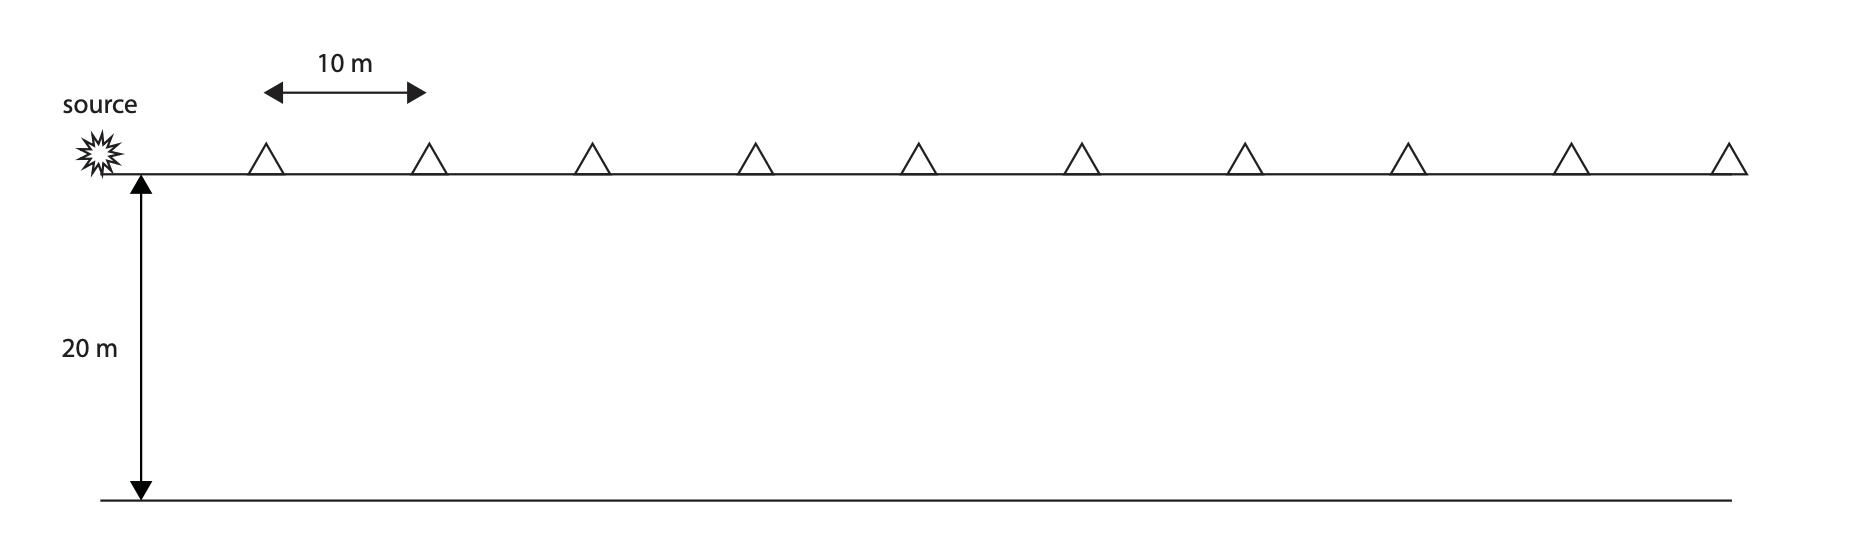

**Problem 2.9:** \
Now we are going to make the model a little more complicated. Create a model to have the layers from the table below. Note that velocity in the table is the velocity of P-wave. Also remember that we assume $ V_s = V_p/1.78$ for the secondary wave velocity.

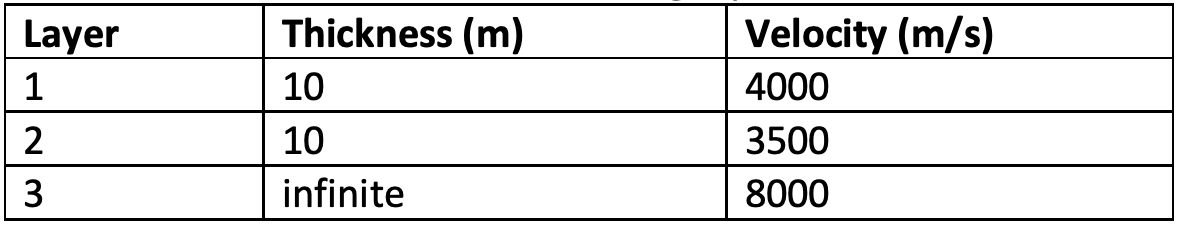

Try to plot the refraction wave traveling along the interface between layer 1 and layer 2. **Does the model return any arrival? Why? (Your response to these questions is what will be counted for credit.)**

In [ ]:
# Below is a prompt for your solution. Type your solutions here, replace "..." with your code
m_layer1 = cake.Material(vp = ..., vs = ...) # layer 1
m_layer2 = cake.Material(vp = ..., vs = ...) # layer 2
m_layer3 = cake.Material(vp = ..., vs = ...) # layer 3

model = cake.LayeredModel()
model.append(cake.Surface(z = 0., mbelow = m_layer1))
model.append(cake.HomogeneousLayer(0., 10., m_layer1, name='layer1'))
model.append(cake.Interface(z = 10., mabove = m_layer1, mbelow = m_layer2, name = "interface1"))
model.append(cake.HomogeneousLayer(10., 20., m_layer2, name='layer2'))
model.append(cake.Interface(z = ..., mabove = m_layer2, mbelow = m_layer3, name = "interface2"))
model.append(cake.HomogeneousLayer(..., ..., m_layer3, name='layer3'))

source_depth = 0.01 # in meters
distances = np.arange(10, 101, 10) * cake.m2d  # convert meter to degree
phase = cake.PhaseDef('Pv_(interface1)p')

for arrival in model.arrivals(distances, phases=phase, zstart=source_depth):
    print('%13g %13g' % (arrival.x*cake.d2m, arrival.t))

We have just identified a problem with the seismic refraction method: **refracted waves do not propagate through a low-velocity layer!** As a result, we cannot determine the wave speed or thickness of a low-velocity layer. This highlights the importance of using multiple methods in geophysical studies. As you'll learn next week, low velocity layers can be detected with a reflection study.

## Section 3: Dipping Layers
Let's try **dipping layers**. The problems in this section will follow the scenario below. 

We are surveying using a forward shot source at the surface, located 10 m from the first geophone, in a 10-geophone line. For the reverse shot, the source is located at 10 m from the last geophone. The spacing between geophones is 10 m. See the schematic below.

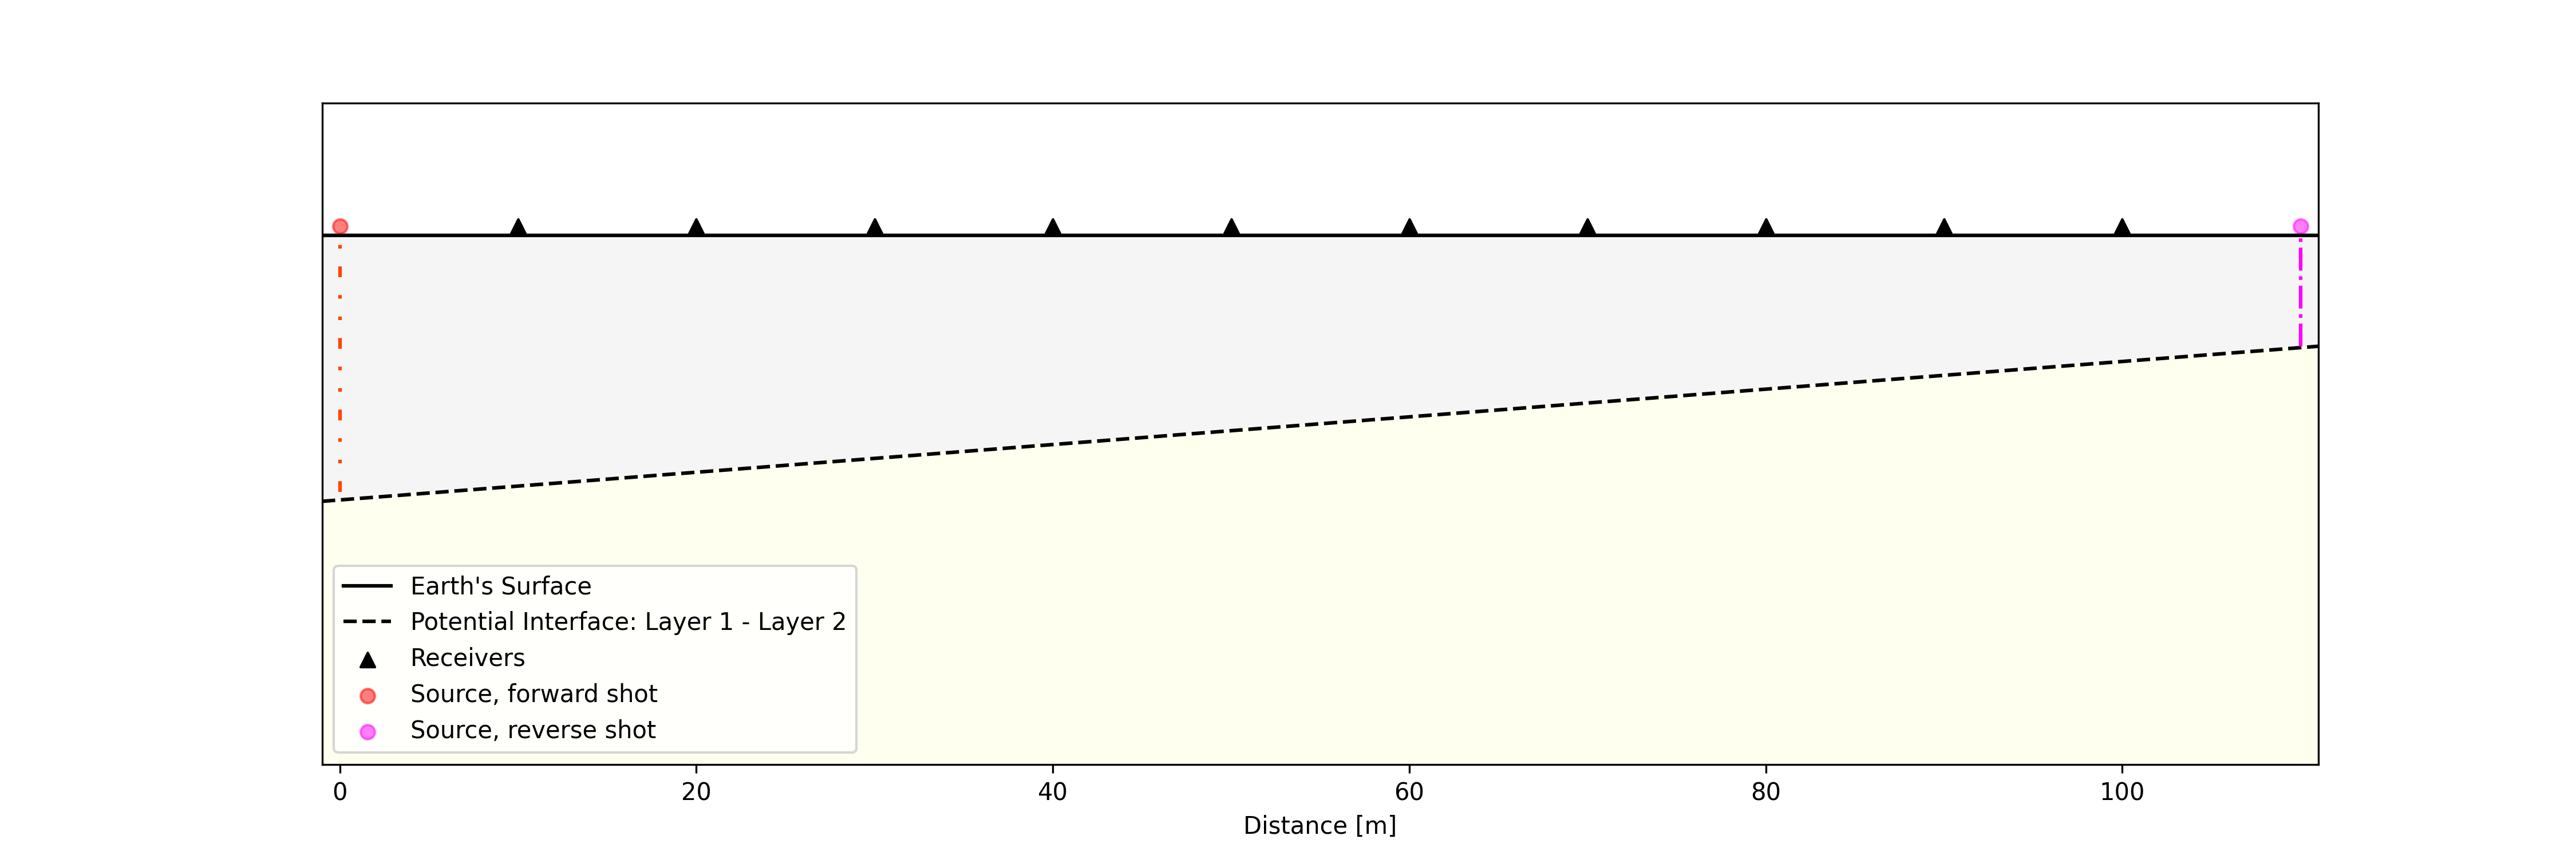

You have performed your survey, and now you want to know what's hiding under the surface. The data you get back from your survey is plotted below as forward and reverse shot travel time curves.

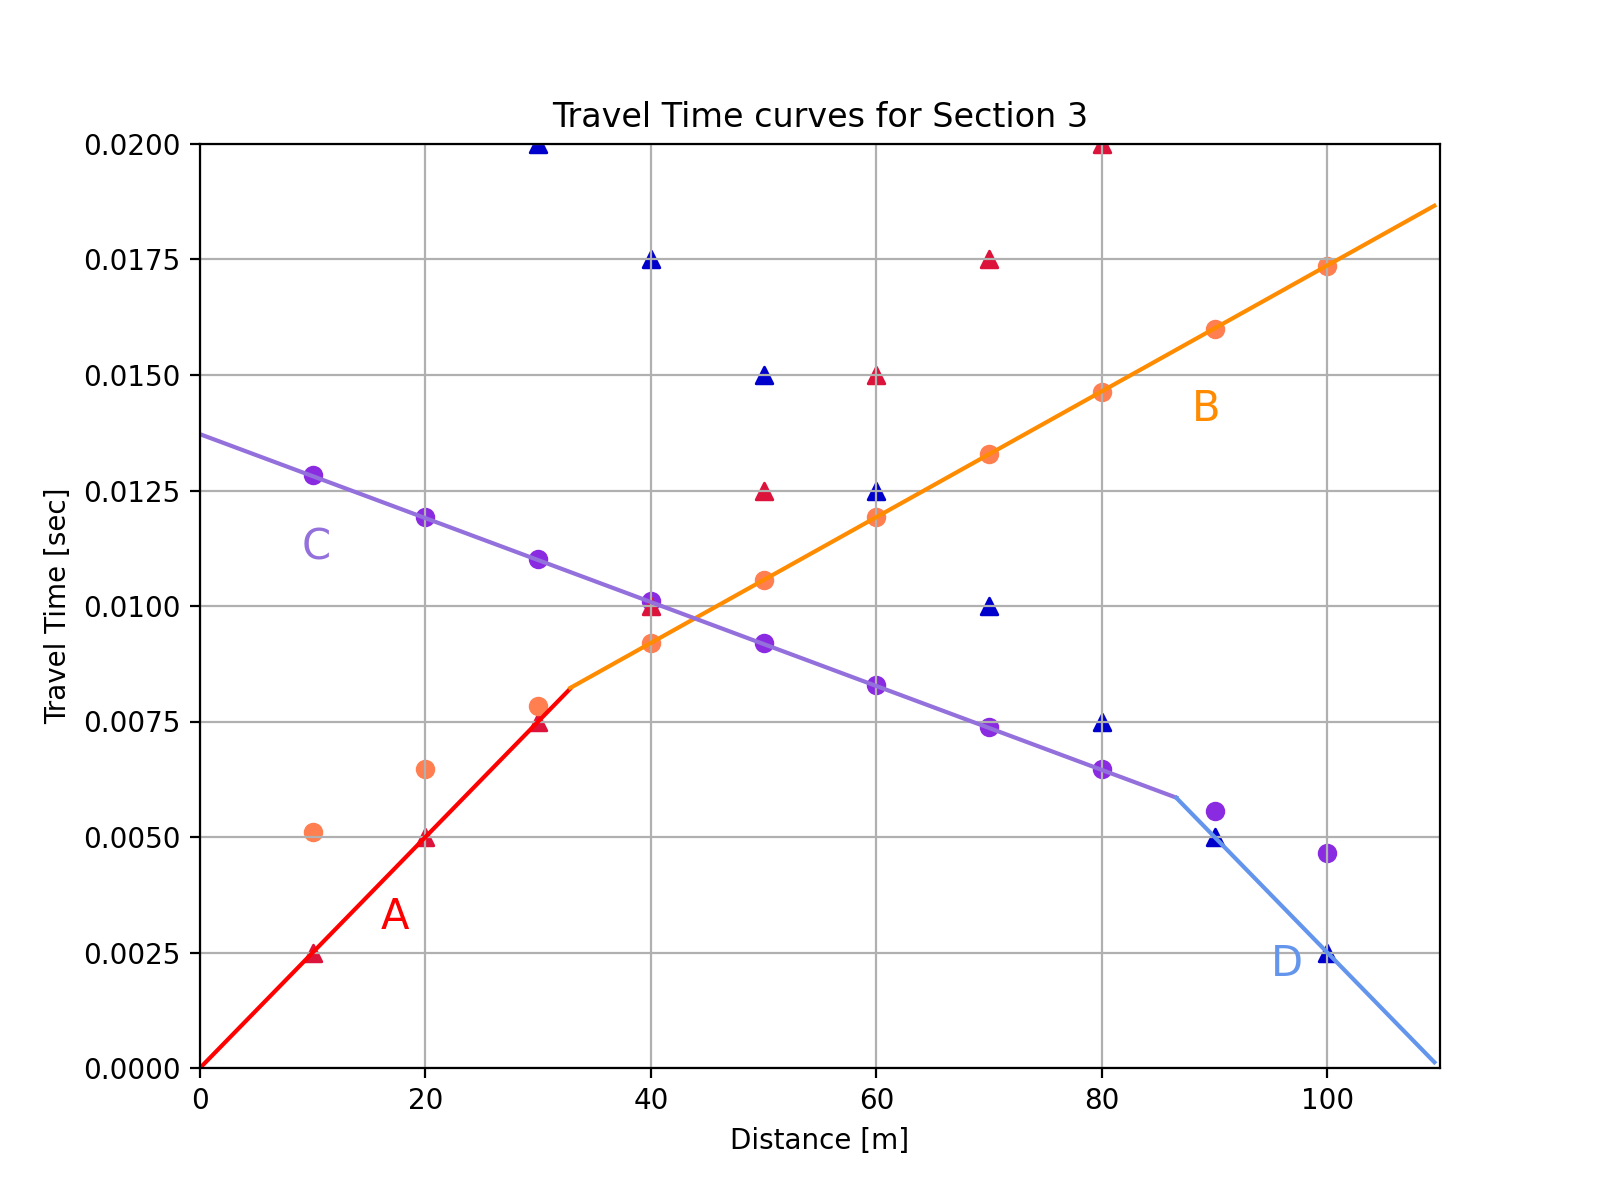

**Problem 3.1:** \
Refer to the above plot.
* Identify which curve represents the first arrivals from the forward shot and which represents the reverse shot. _(0.5 points)_ 
* Using the letters on the plot, identify which parts of each curve represent the direct wave arrivals. What does the rest of each curve represent? _(0.5 points)_ 
* How can you tell from the plot which way the interface is dipping?  _(1 point)_

_Double-click this cell and replace this text with your answers to 3.1. Run the cell when you're done._

**Problem 3.2:** \
Use the equations
\begin{equation}
\tag{3.1}
\beta = \frac{1}{2} \left( sin^{-1} \left(\frac{v_1}{v_{2d}} \right) - sin^{-1} \left(\frac{v_1}{v_{2u}} \right) \right),
\end{equation}

\begin{equation}
\tag{3.2}
\theta_{i_c} = \frac{1}{2} \left( sin^{-1} \left(\frac{v_1}{v_{2d}} \right) + sin^{-1} \left(\frac{v_1}{v_{2u}} \right) \right),
\end{equation}

\begin{equation}
\tag{3.3}
v_2 = \frac{v_1}{sin \theta_{i_c}}.
\end{equation}

With the variables defined as:
* $v_1 =$ true velocity of the top layer
* $v_2 =$ true velocity of the second layer
* $v_{2u} =$ apparent velocity of the second layer, according to the waves traveling up-dip
* $v_{2d} =$ apparent velocity of the second layer, according to the waves traveling down-dip
* $\beta =$ dip angle
* $\theta_{i_c} =$ is the critical angle for the second layer

This is only information you have:
* $v_1 = 4000$ in units of [m/s].

First estimate the apparent velocities of the second layer using the travel time plot above, and then find $v_2$ using equations 3.2 and 3.3. **Show your work**. If you need to manipulate the equations to solve the problem, either add your work in a new Markdown cell below, or comment it in above your code.

Store your values for $v_{2u}$ and $v_{2d}$ as `v_2u` and `v_2d`, respectively. Store your solution for $v_2$ as `v_2`. _(4 points)_

In [ ]:
# put your code here to address Problem 3.2

**Problem 3.3:** \
Calculate the value for the dip of the layer, using your answers to 3.2 and the equations provided. Store your solution as `beta`. _(1 point)_

In [ ]:
# put your code here to address Problem 3.3

**Problem 3.4:** \
Do you think your values for $v_2$ and $\beta$ are accurate? What are some sources of error in your solution? _(1 point)_

_Double-click this cell and replace this text with your answers to 3.4. Run the cell when you're done._

## Section 4: Ledgewood Landslide

Okay, now for the fun part! We are going to explore a real problem.

You may have heard of the Ledgewood Landslide that happened on Whidbey Island on March 27, 2013. Almost 200,000 yd3 (40,000 dump truck loads) of dirt slipped down the hillside. While the slide area for the Ledgewood Landslide only extends about 400-500 meters across the hillside, the entire coastline is a giant landslide scarp, where similar landslides have been happening for the last 10,000 years.

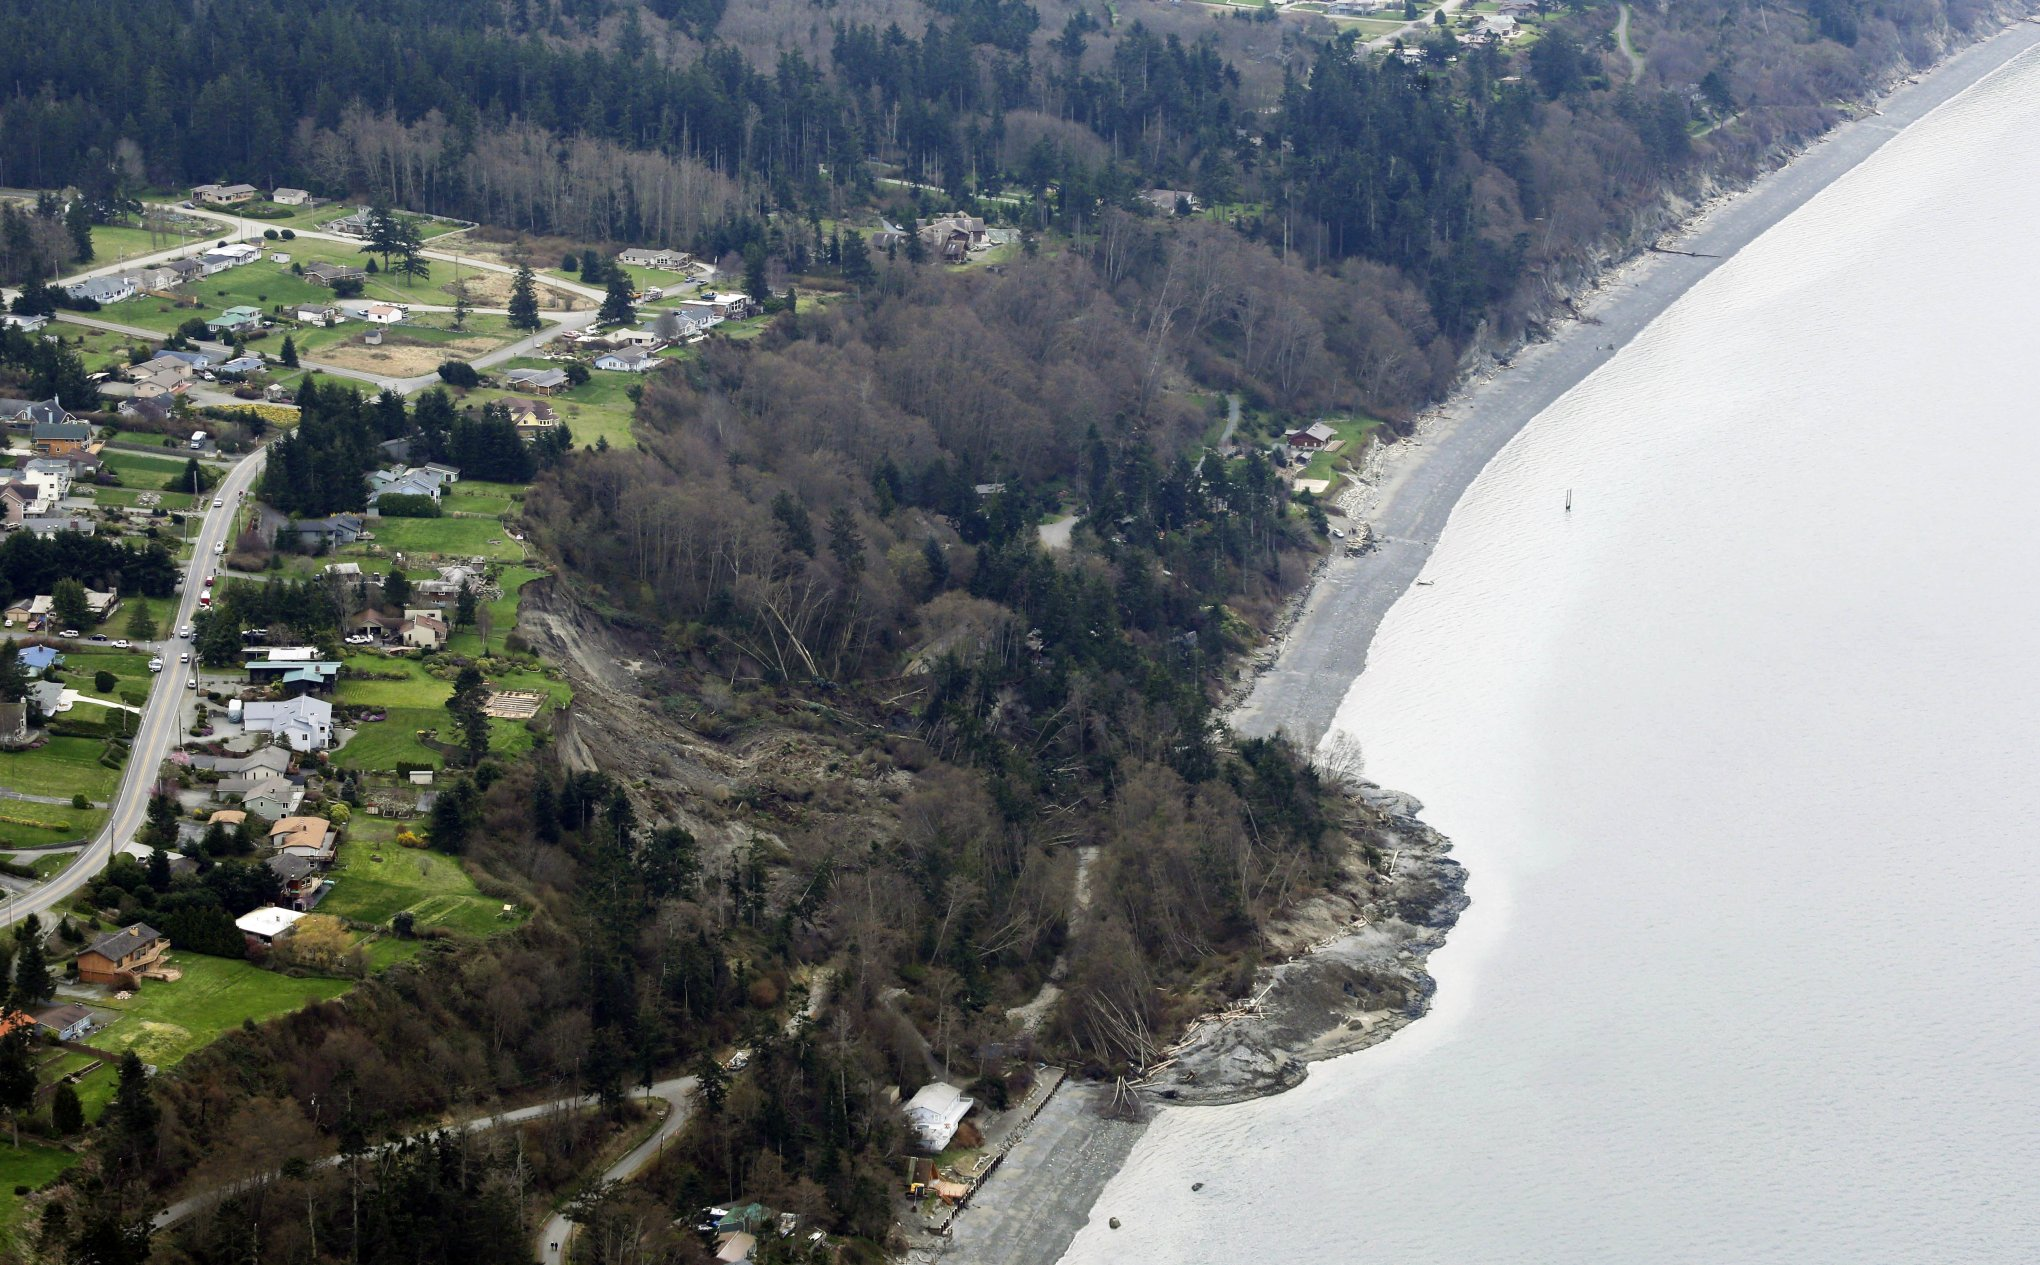

**Ledgewood Landslide, March 2013.** Photo by Ted S. Warren / The Associated Press

Why is this coastline so susceptible to landslides? There are a few reasons. One is that the ocean erodes away at the base of the hillside making it unstable. Additionally, lots of rain tends to saturate the soil, making it weaker. Another reason has to do with the types of layers in the shallow subsurface. At the base of the hill there is a glacial clay layer. This layer sits under layers of other, coarser glacial deposits. Water can flow through the coarser glacial deposits, but gets trapped above the clay layer, creating an ideal slide plane.


To assess landslide risk, we are going to use seismic refraction to map the top of the clay layer. Somebody already went out and collected the data for us. They set out 50 geophones, spaced 20 meters apart, on the top of the bluff, which is 120 meters higher than the beach. The first geophone is farthest away from the edge and the last geophone is right on the edge of the bluff (see figure below).

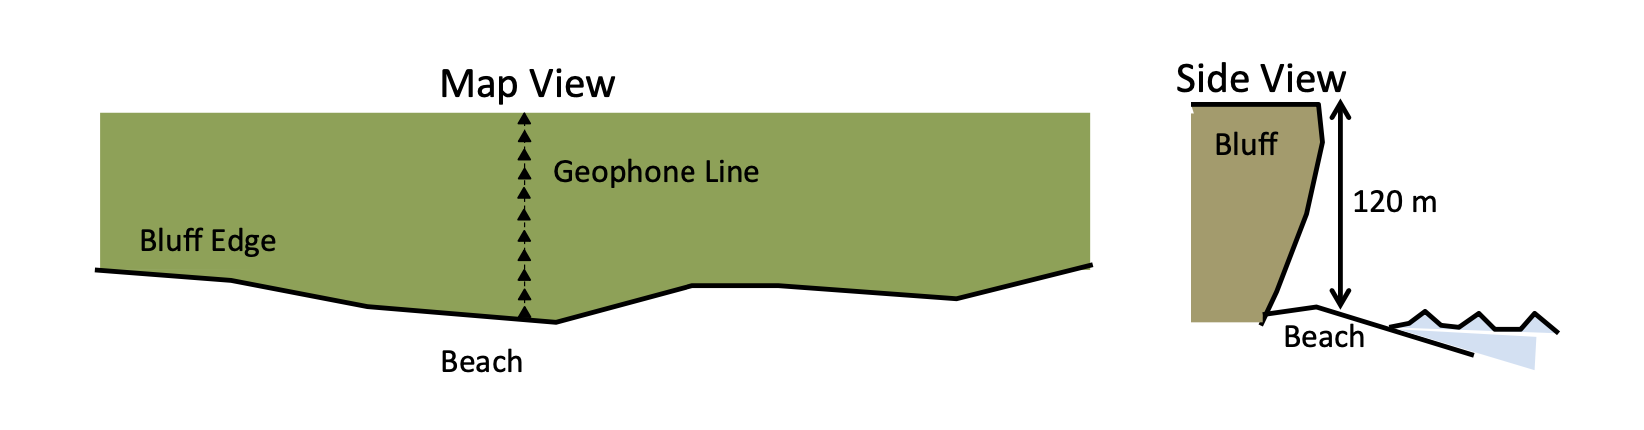

**Problem 4.1:** \
Open the data file `WhidbeyData.txt` and make a plot of the data. Label the forward and reverse shots in a legend. **We will do this question as a tutorial in the lab period.** _(2 points)_

In [ ]:
# first cell for tutorial

**Problem 4.2:** \
How many layers are shown on your travel time plot from 4.1? Are all of the layers dipping? How can you tell? _(2 points)_

_Double-click this cell and replace this text with your answer to 4.2. Run the cell when you're done._

**Problem 4.3:** \
Based on the direction of layer dip (which you should be able to estimate from your plot in 4.1), and the fact that many landslides happen at this beach, how is the layer dip oriented to the beach? Which side of the plot from 4.1 is the beach on (left or right)? Will more landslides happen here in the future, given the direction of dip? _(2 points)_

_Double-click this cell and replace this text with your answers to 4.3. Be sure to address each question. Run the cell when you're done._

### **Submission instructions:** 
Make sure you have run **all** cells in your notebook, in order, before saving and submitting, so that all images/graphs appear in the output in your submission. Save the final version of this notebook with your name in the filename and at the beginning (where there is a spot for it). Upload a copy of your notebook and figure for Question 2.8 to Canvas. 

This concludes Lab 5. 

_Congrats, you made it!_